# Image Segmentation for Autonomous Vehicles Using K-Means Clustering

**Course:** Mathematical Foundations of Artificial Intelligence  
**University:** Jagiellonian University  
**Authors:** Łukasz Rudnik, Mikołaj Suchan  
**Year:** 2025/2026

K-means image segmentation on Cityscapes: comparing color-only segmentation `[R,G,B]` with color+position segmentation `[R,G,B,x,y]`, the impact of the number of clusters and the `lambda` weight, evaluated by IoU. Tested on the city of **Cologne**.

> A heavy **overview demo** (one PNG per frame + an HTML gallery for convenient browsing) is generated by a separate script `generate_demo.py`. In this notebook, the visualization section showcases hand-selected images.

## Setup and Imports

In [2]:
import os
import glob
import csv
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from PIL import Image

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

DATA_DIR = "data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)
print("ready")

ready


## Configuration

All parameters in one place (same keys as in `generate_demo.py`).

In [3]:
CONFIG = {
    "split": "train",        # train / val
    "city": "cologne",       # city to read
    "image_names": [],       # empty -> first num_images frames
    "num_images": 150,        # how many cologne frames to evaluate
    "resize": (512, 256),    # (W, H); None = full resolution
    "demo_k_values": [8, 12, 16],
    "demo_lambda_values": [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0],
    "color_space": "rgb",   # "rgb" or "lab"
    "minibatch": True,
    "n_init": 5,
    "random_state": 42,
    "ignore_ids": (0, 1, 2, 3, 4, 5, 6, 9, 10, 14, 15, 16, 18, 29, 30),  # void classes
    # --- final visualization (section 6) ---
    "picked": [                         # frames to show in the final demo (from the gallery)
        "cologne_000060_000019_leftImg8bit",
        "cologne_000145_000019_leftImg8bit",
        "cologne_000045_000019_leftImg8bit",
        "cologne_000019_000019_leftImg8bit",
        "cologne_000135_000019_leftImg8bit",
        "cologne_000056_000019_leftImg8bit",
    ],
    "final_k": 12,                      # number of clusters for the final demo
    "final_lambdas": [0.5, 1.0, 2.0],   # spatial weights shown in the final demo
}
CONFIG

{'split': 'train',
 'city': 'cologne',
 'image_names': [],
 'num_images': 150,
 'resize': (512, 256),
 'demo_k_values': [8, 12, 16],
 'demo_lambda_values': [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0],
 'color_space': 'rgb',
 'minibatch': True,
 'n_init': 5,
 'random_state': 42,
 'ignore_ids': (0, 1, 2, 3, 4, 5, 6, 9, 10, 14, 15, 16, 18, 29, 30),
 'picked': ['cologne_000060_000019_leftImg8bit',
  'cologne_000145_000019_leftImg8bit',
  'cologne_000045_000019_leftImg8bit',
  'cologne_000019_000019_leftImg8bit',
  'cologne_000135_000019_leftImg8bit',
  'cologne_000056_000019_leftImg8bit'],
 'final_k': 12,
 'final_lambdas': [0.5, 1.0, 2.0]}

## 1. Load Data

We scale the image bilinearly, and the labels using the nearest neighbor method (`NEAREST`) — otherwise, non-existent class IDs would be created.

In [4]:
def find_pairs(split, city, num_images, image_names=None):
    img_dir = os.path.join(DATA_DIR, "leftImg8bit", split, city)
    gt_dir = os.path.join(DATA_DIR, "gtFine", split, city)
    img_paths = sorted(glob.glob(os.path.join(img_dir, "*_leftImg8bit.png")))
    pairs = []
    if image_names:
        by_base = {os.path.basename(p).replace("_leftImg8bit.png", ""): p for p in img_paths}
        for name in image_names:
            base = name.replace("_leftImg8bit.png", "").replace("_leftImg8bit", "")
            ip = by_base.get(base)
            if ip is None:
                print(f"WARNING: {base} not found, skipping"); continue
            lp = os.path.join(gt_dir, base + "_gtFine_labelIds.png")
            if os.path.exists(lp):
                pairs.append((ip, lp, base))
        return pairs
    for ip in img_paths:
        base = os.path.basename(ip).replace("_leftImg8bit.png", "")
        lp = os.path.join(gt_dir, base + "_gtFine_labelIds.png")
        if os.path.exists(lp):
            pairs.append((ip, lp, base))
        if len(pairs) >= num_images:
            break
    return pairs

def load_image(path, resize):
    img = Image.open(path).convert("RGB")
    if resize:
        img = img.resize(resize, Image.BILINEAR)
    return np.asarray(img)

def load_label(path, resize):
    lbl = Image.open(path)
    if resize:
        lbl = lbl.resize(resize, Image.NEAREST)
    return np.asarray(lbl)

pairs = find_pairs(CONFIG["split"], CONFIG["city"], CONFIG["num_images"], CONFIG.get("image_names"))
assert pairs, "No image/label pairs found - check DATA_DIR, split, city."
data = []
for ip, lp, base in pairs:
    data.append({"image": load_image(ip, CONFIG["resize"]),
                 "gt": load_label(lp, CONFIG["resize"]), "base": base})
print(f"loaded {len(data)} images from city '{CONFIG['city']}'")

loaded 150 images from city 'cologne'


## 2. Prepare Features

We normalize color and coordinates to `[0,1]`, and multiply the position by `lambda`:
`[r,g,b]` (color) or `[r,g,b, λ·x, λ·y]` (color+position). Without normalization, the coordinates would dominate the color.

In [5]:
def image_features(img, color_space):
    # color computed once; coords returned separately so lambda can be applied cheaply
    H, W = img.shape[:2]
    if color_space == "lab":
        from skimage.color import rgb2lab
        color = rgb2lab(img / 255.0).reshape(-1, 3) / np.array([100.0, 128.0, 128.0])
    else:
        color = img.reshape(-1, 3).astype(np.float64) / 255.0
    ys, xs = np.mgrid[0:H, 0:W]
    xs = xs.reshape(-1, 1) / max(W - 1, 1)
    ys = ys.reshape(-1, 1) / max(H - 1, 1)
    return color, xs, ys

_c, _x, _y = image_features(data[0]["image"], CONFIG["color_space"])
print("color:", _c.shape, "| color+pos would be:", np.hstack([_c, _x, _y]).shape)

color: (131072, 3) | color+pos would be: (131072, 5)


## 3. K-Means + IoU

Machinery: `run_kmeans`, cluster→dominant GT class mapping (majority voting), `mean_iou` (IoU per class, averaged; void classes ignored). Plus official Cityscapes colors/names and coloring functions.

In [6]:
def run_kmeans(features, k, random_state=42, minibatch=False, n_init=5):
    if minibatch:
        km = MiniBatchKMeans(n_clusters=k, n_init=n_init, batch_size=4096, random_state=random_state)
    else:
        km = KMeans(n_clusters=k, n_init=n_init, random_state=random_state)
    return km.fit_predict(features)

def map_clusters_to_classes(cluster_map, gt_map):
    lut = np.zeros(int(cluster_map.max()) + 1, dtype=np.int64)
    for c in np.unique(cluster_map):
        vals, counts = np.unique(gt_map[cluster_map == c], return_counts=True)
        lut[c] = int(vals[np.argmax(counts)])
    return lut[cluster_map]

def mean_iou(pred_map, gt_map, ignore_ids=(0,)):
    classes = [c for c in np.unique(gt_map) if c not in ignore_ids]
    per_class = {}
    for c in classes:
        p = pred_map == c; g = gt_map == c
        inter = np.logical_and(p, g).sum(); union = np.logical_or(p, g).sum()
        if union > 0:
            per_class[int(c)] = inter / union
    miou = float(np.mean(list(per_class.values()))) if per_class else 0.0
    return miou, per_class

CITYSCAPES_NAMES = {
    7: "road", 8: "sidewalk", 11: "building", 12: "wall", 13: "fence", 17: "pole",
    19: "traffic light", 20: "traffic sign", 21: "vegetation", 22: "terrain", 23: "sky",
    24: "person", 25: "rider", 26: "car", 27: "truck", 28: "bus", 31: "train",
    32: "motorcycle", 33: "bicycle",
}
CITYSCAPES_COLORS = {
    7: (128, 64, 128), 8: (244, 35, 232), 11: (70, 70, 70), 12: (102, 102, 156),
    13: (190, 153, 153), 17: (153, 153, 153), 19: (250, 170, 30), 20: (220, 220, 0),
    21: (107, 142, 35), 22: (152, 251, 152), 23: (70, 130, 180), 24: (220, 20, 60),
    25: (255, 0, 0), 26: (0, 0, 142), 27: (0, 0, 70), 28: (0, 60, 100),
    31: (0, 80, 100), 32: (0, 0, 230), 33: (119, 11, 32),
}

def colorize_classes(class_map):
    out = np.zeros(class_map.shape + (3,), dtype=np.uint8)
    for cid, col in CITYSCAPES_COLORS.items():
        out[class_map == cid] = col
    return out

def colorize_hybrid(cluster_map, gt_map):
    from collections import defaultdict
    out = np.zeros(cluster_map.shape + (3,), dtype=np.uint8)
    by_class = defaultdict(list)
    for c in np.unique(cluster_map):
        vals, cnt = np.unique(gt_map[cluster_map == c], return_counts=True)
        by_class[int(vals[np.argmax(cnt)])].append(int(c))
    for cls, clusters in by_class.items():
        base = np.array(CITYSCAPES_COLORS.get(cls, (110, 110, 110)), dtype=np.float64)
        n = len(clusters)
        for i, c in enumerate(sorted(clusters)):
            if n == 1:
                col = base
            else:
                t = -0.4 + 0.8 * (i / (n - 1))
                col = base + (255.0 - base) * t if t >= 0 else base * (1.0 + t)
            out[cluster_map == c] = np.clip(col, 0, 255).astype(np.uint8)
    return out

print("helpers ready;", len(CITYSCAPES_NAMES), "evaluation classes")

helpers ready; 19 evaluation classes


In [8]:
def colorize_random(cluster_map, seed=0):
    rng = np.random.default_rng(seed)
    n = int(cluster_map.max()) + 1
    palette = rng.integers(0, 256, size=(n, 3), dtype=np.uint8)
    return palette[cluster_map]

print("colorize_random ready")

colorize_random ready


## 4. Run segmentation & collect metrics

Here is where **everything kicks off**: for each frame, we cluster the color variant (for each `k`) and color+position (for each `k` × `λ`), calculate mIoU, and collect the results. No plotting — just pure numbers (plotting the demo is in `generate_demo.py`).

> Heavy cell: `num_images × |k| × (1+|λ|)` k-means fits. Set `num_images=3` for a test run.

In [ ]:
ks = CONFIG["demo_k_values"]
lams = CONFIG["demo_lambda_values"]
records = []
agg_color = {k: [] for k in ks}
agg_pos = {(k, lam): [] for k in ks for lam in lams}

for i, d in enumerate(data, 1):
    H, W = d["image"].shape[:2]
    color, xs, ys = image_features(d["image"], CONFIG["color_space"])
    for k in ks:
        lab = run_kmeans(color, k, CONFIG["random_state"], CONFIG["minibatch"], CONFIG["n_init"]).reshape(H, W)
        m = mean_iou(map_clusters_to_classes(lab, d["gt"]), d["gt"], CONFIG["ignore_ids"])[0]
        records.append((d["base"], k, "rgb", "", m)); agg_color[k].append(m)
        for lam in lams:
            feats = np.hstack([color, lam * xs, lam * ys])
            lab = run_kmeans(feats, k, CONFIG["random_state"], CONFIG["minibatch"], CONFIG["n_init"]).reshape(H, W)
            m = mean_iou(map_clusters_to_classes(lab, d["gt"]), d["gt"], CONFIG["ignore_ids"])[0]
            records.append((d["base"], k, "pos", lam, m)); agg_pos[(k, lam)].append(m)
    if i % 10 == 0 or i == len(data):
        print(f"computed {i}/{len(data)} images")

computed 10/150 images
computed 20/150 images
computed 30/150 images
computed 40/150 images
computed 50/150 images
computed 60/150 images
computed 70/150 images
computed 80/150 images
computed 90/150 images
computed 100/150 images
computed 110/150 images
computed 120/150 images
computed 130/150 images
computed 140/150 images
computed 150/150 images


## 5. IoU Evaluation

Saving all numbers to CSV (for sorting) and averages across images.

In [113]:
with open(os.path.join(RESULTS_DIR, "iou_results.csv"), "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["image", "k", "method", "lambda", "miou"])
    for base, k, method, lam, m in records:
        w.writerow([base, k, method, lam, f"{m:.4f}"])
print(f"wrote {len(records)} rows to results/iou_results.csv")

print("\nMean mIoU over all images:")
for k in ks:
    best = max(lams, key=lambda lam: np.mean(agg_pos[(k, lam)]))
    print(f"  k={k:>3}  color-only={np.mean(agg_color[k]):.3f}   "
          f"best pos: lambda={best} ({np.mean(agg_pos[(k, best)]):.3f})")

wrote 3600 rows to results/iou_results.csv

Mean mIoU over all images:
  k=  8  color-only=0.148   best pos: lambda=0.75 (0.194)
  k= 12  color-only=0.160   best pos: lambda=1.0 (0.223)
  k= 16  color-only=0.166   best pos: lambda=1.5 (0.245)


## 6. Visualization

For selected frames (`CONFIG["picked"]`), we draw a separate figure for each (`k=CONFIG["final_k"]`), saved as `results/final/<frame>_final.png` and shown inline.

- **Top row** — colors according to Cityscapes classes (after mapping clusters to GT): original, ground truth, RGB only, and position for subsequent `λ`.
- **Bottom row** — the same segmentations, but in **random colors**. It shows that without interpretation based on GT, raw clusters are unreadable — only mapping to classes gives them meaning.

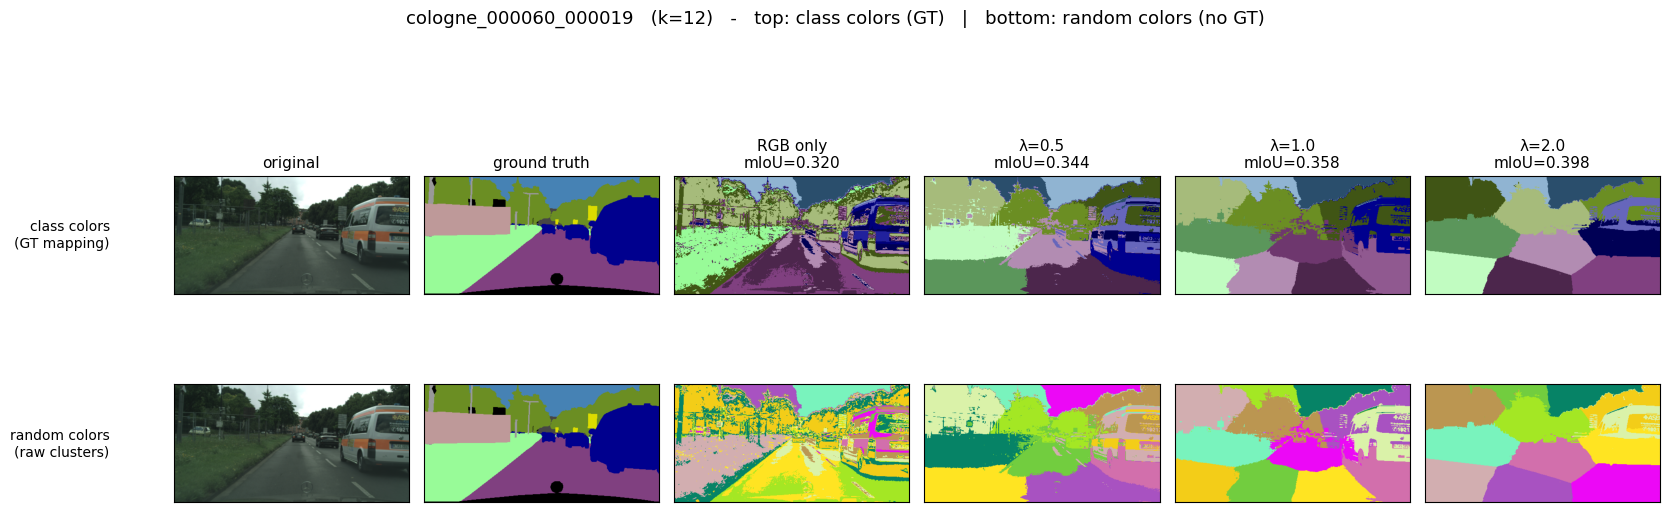

saved results/final/cologne_000060_000019_final.png


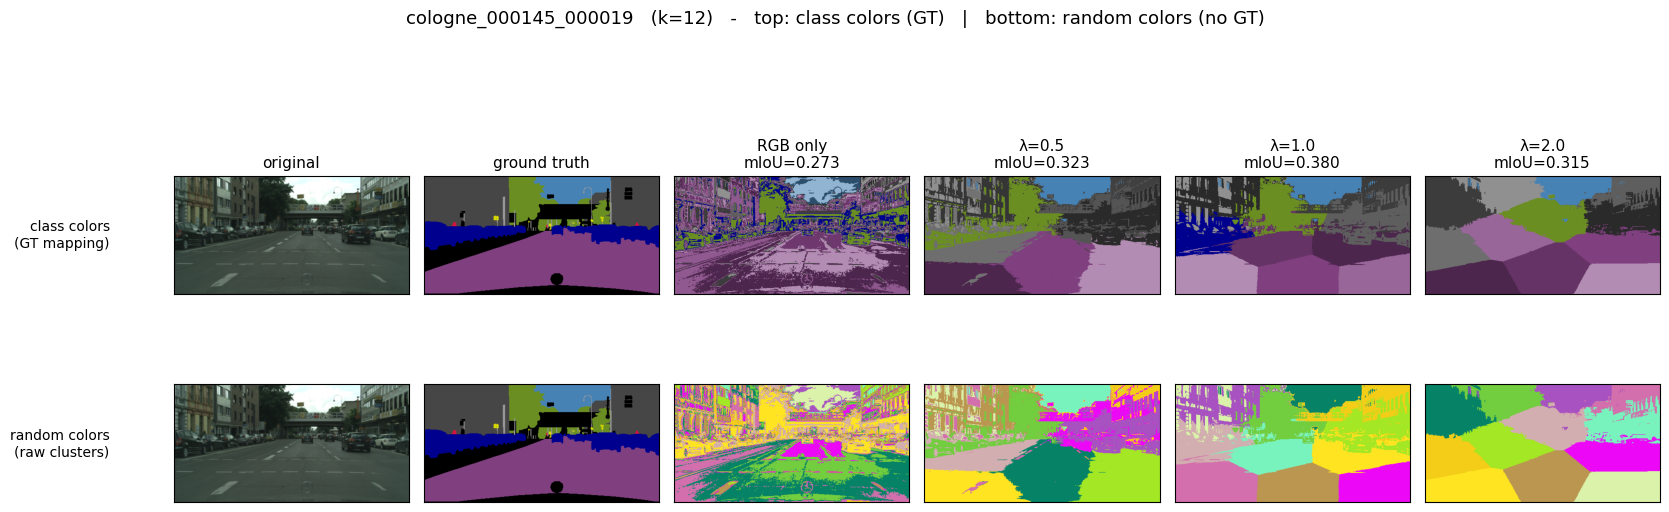

saved results/final/cologne_000145_000019_final.png


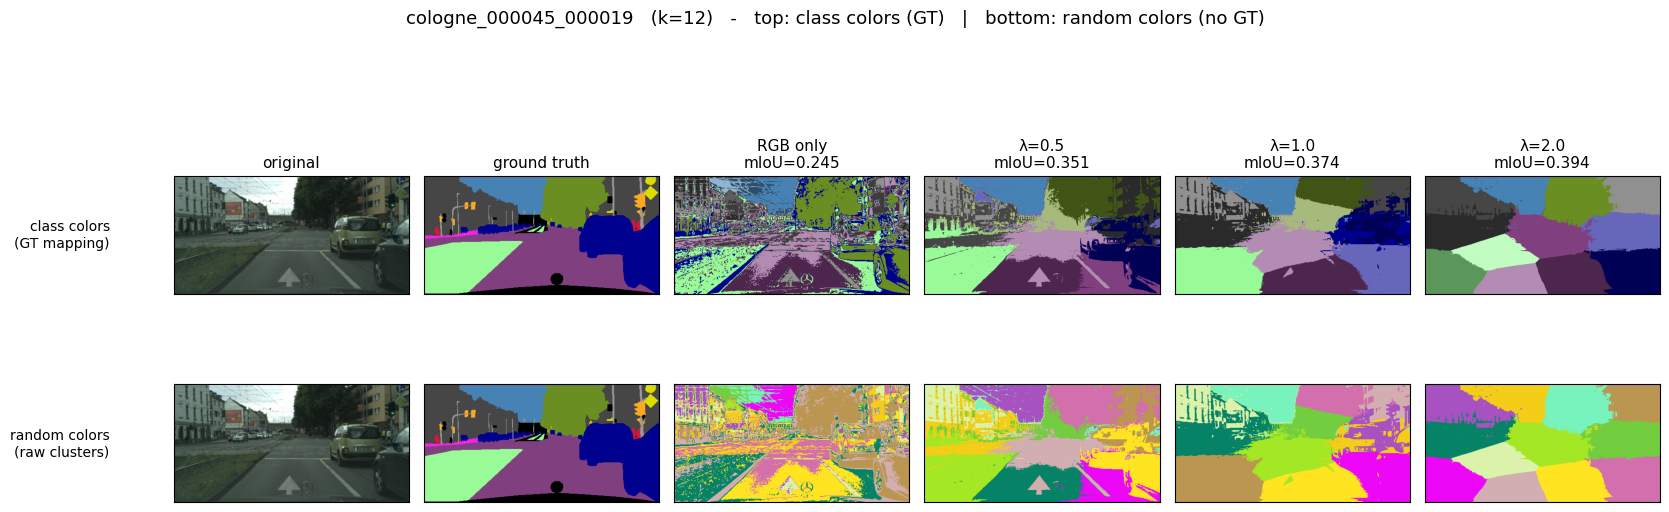

saved results/final/cologne_000045_000019_final.png


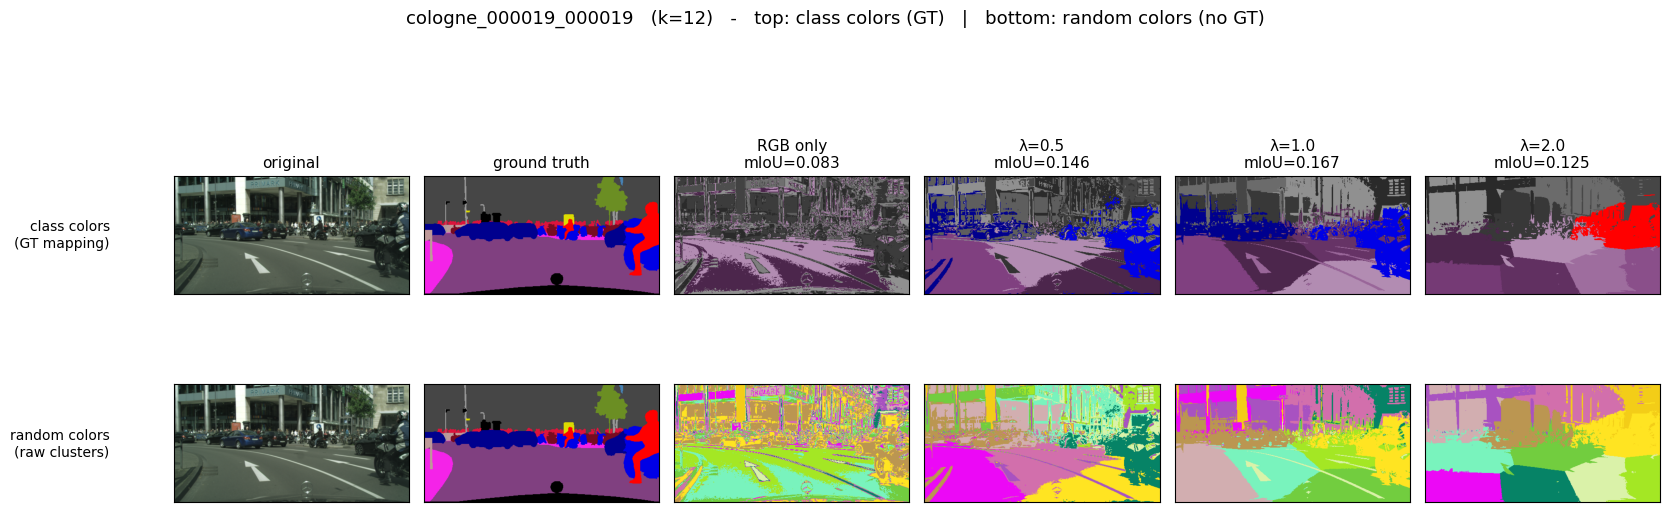

saved results/final/cologne_000019_000019_final.png


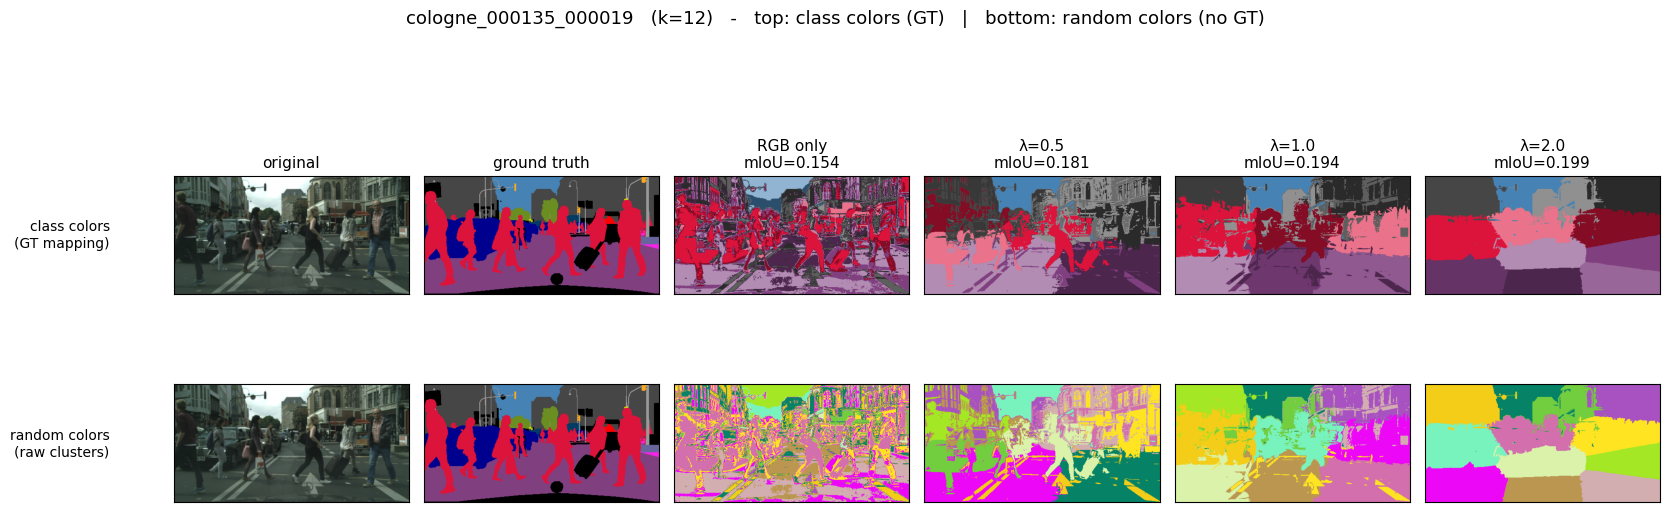

saved results/final/cologne_000135_000019_final.png


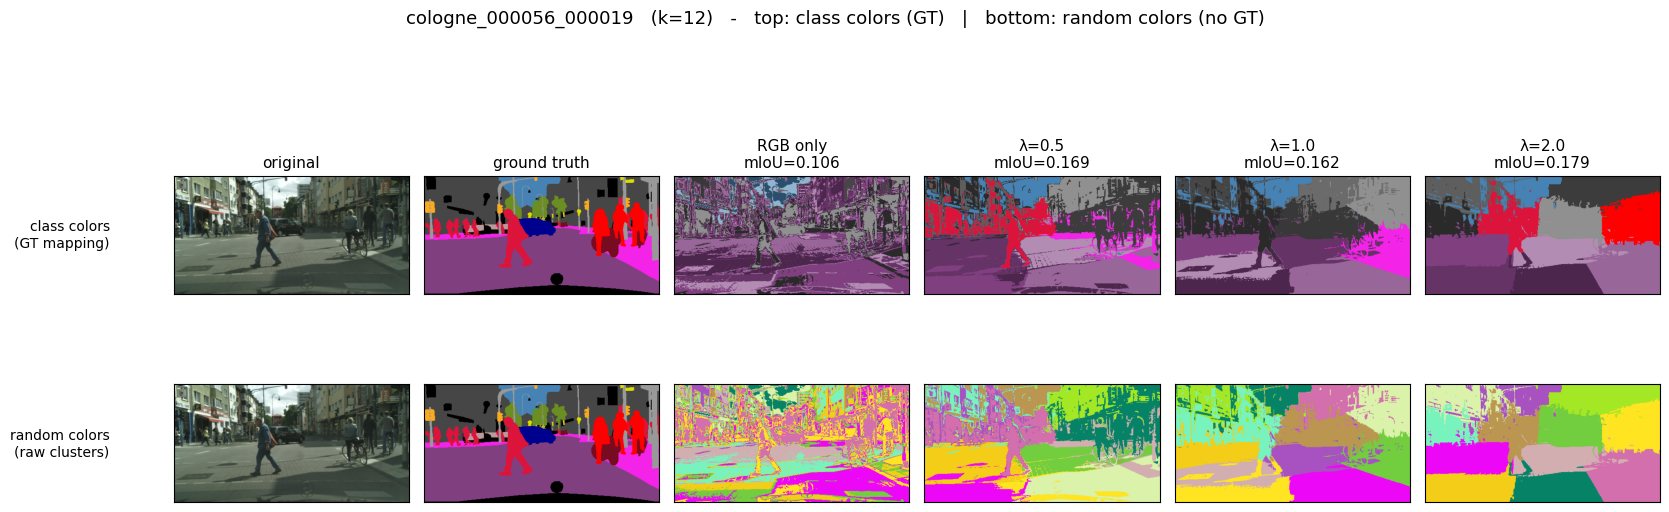

saved results/final/cologne_000056_000019_final.png


In [9]:
FINAL_DIR = os.path.join(RESULTS_DIR, "final")
os.makedirs(FINAL_DIR, exist_ok=True)

picked = CONFIG["picked"]
fk = CONFIG["final_k"]
flams = CONFIG["final_lambdas"]

if not picked:
    print("Fill CONFIG['picked'] with frames chosen from the gallery and re-run.")
else:
    pp = find_pairs(CONFIG["split"], CONFIG["city"], len(picked), picked)
    for ip, lp, base in pp:
        img = load_image(ip, CONFIG["resize"]); gt = load_label(lp, CONFIG["resize"])
        H, W = img.shape[:2]
        color, xs, ys = image_features(img, CONFIG["color_space"])

        # cluster once per variant at the final k
        seg_rgb = run_kmeans(color, fk, CONFIG["random_state"], CONFIG["minibatch"], CONFIG["n_init"]).reshape(H, W)
        variants = [("RGB only", seg_rgb)]
        for lam in flams:
            feats = np.hstack([color, lam * xs, lam * ys])
            s = run_kmeans(feats, fk, CONFIG["random_state"], CONFIG["minibatch"], CONFIG["n_init"]).reshape(H, W)
            variants.append((f"\u03bb={lam}", s))
        mious = [mean_iou(map_clusters_to_classes(s, gt), gt, CONFIG["ignore_ids"])[0] for _, s in variants]

        gt_rgb = colorize_classes(gt)
        ncols = 2 + len(variants)          # original, ground truth, + variants
        fig, ax = plt.subplots(2, ncols, figsize=(2.8 * ncols, 6.2), squeeze=False)

        # top row: GT-mapped (meaningful) colors
        ax[0][0].imshow(img);    ax[0][0].set_title("original", fontsize=11)
        ax[0][1].imshow(gt_rgb); ax[0][1].set_title("ground truth", fontsize=11)
        for j, (name, s) in enumerate(variants):
            ax[0][2 + j].imshow(colorize_hybrid(s, gt))
            ax[0][2 + j].set_title(f"{name}\nmIoU={mious[j]:.3f}", fontsize=11)

        # bottom row: GT still nice, segmentations in RANDOM colors (no GT interpretation)
        ax[1][0].imshow(img)
        ax[1][1].imshow(gt_rgb)
        for j, (name, s) in enumerate(variants):
            ax[1][2 + j].imshow(colorize_random(s, seed=1))

        for r in range(2):
            for c in range(ncols):
                ax[r][c].set_xticks([]); ax[r][c].set_yticks([])
        ax[0][0].set_ylabel("class colors\n(GT mapping)", fontsize=10, rotation=0, ha="right", va="center", labelpad=46)
        ax[1][0].set_ylabel("random colors\n(raw clusters)", fontsize=10, rotation=0, ha="right", va="center", labelpad=46)
        fig.suptitle(f"{base}   (k={fk})   -   top: class colors (GT)   |   bottom: random colors (no GT)", fontsize=13)
        plt.tight_layout(rect=[0, 0, 1, 0.95])
        out = os.path.join(FINAL_DIR, f"{base}_final.png")
        fig.savefig(out, dpi=120, bbox_inches="tight")
        plt.show()
        print("saved", out)


## 7. Analysis

A collective plot of mIoU vs number of clusters, a curve for each `λ` + the *color only* reference line, and a breakdown of IoU per class for the best configuration.

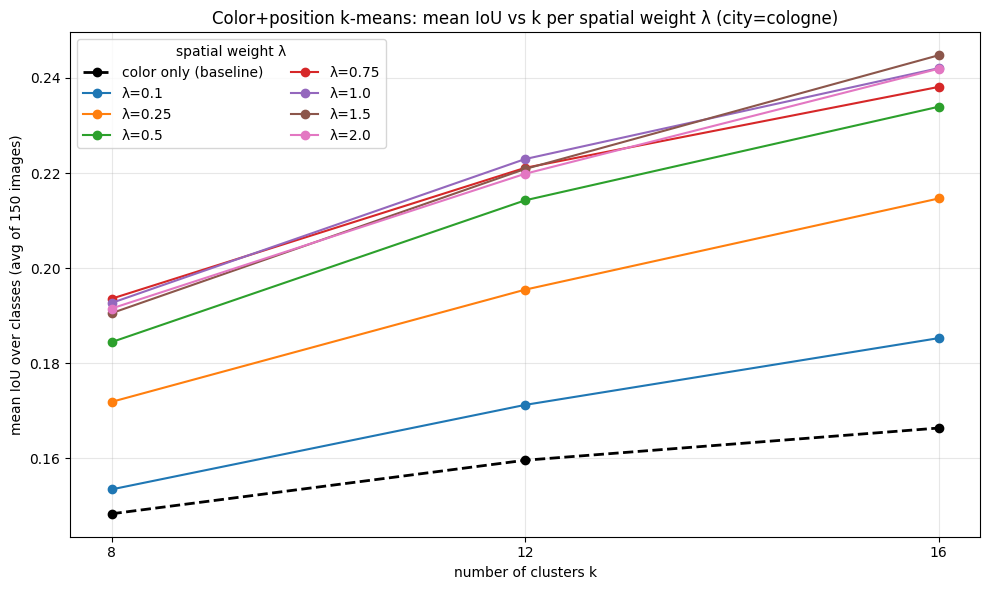

Best color+pos setting: k=16, lambda=1.5 (mIoU=0.245)

                 | k=16, lambda=1.5     | k=12, lambda=0.5    
-----------------------------------------------------------------
road             | 0.710                | 0.692               
sidewalk         | 0.146                | 0.095               
building         | 0.561                | 0.479               
wall             | 0.087                | 0.041               
fence            | 0.033                | 0.009               
pole             | 0.001                | 0.001               
traffic light    | 0.000                | 0.000               
traffic sign     | 0.007                | 0.003               
vegetation       | 0.449                | 0.386               
terrain          | 0.095                | 0.064               
sky              | 0.657                | 0.659               
person           | 0.029                | 0.014               
rider            | 0.004                | 0.000             

In [115]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ks, [np.mean(agg_color[k]) for k in ks], "k--o", linewidth=2, label="color only (baseline)")
for lam in lams:
    ax.plot(ks, [np.mean(agg_pos[(k, lam)]) for k in ks], "o-", label=f"\u03bb={lam}")
ax.set_xlabel("number of clusters k")
ax.set_ylabel(f"mean IoU over classes (avg of {len(data)} images)")
ax.set_title(f"Color+position k-means: mean IoU vs k per spatial weight \u03bb (city={CONFIG['city']})")
ax.legend(title="spatial weight \u03bb", ncol=2); ax.set_xticks(ks); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "miou_vs_k_per_lambda.png"), dpi=120, bbox_inches="tight")
plt.show()

best_kl = max(((k, lam) for k in ks for lam in lams), key=lambda kl: np.mean(agg_pos[kl]))
print(f"Best color+pos setting: k={best_kl[0]}, lambda={best_kl[1]} (mIoU={np.mean(agg_pos[best_kl]):.3f})\n")

# --- best setting ---
bk1, blam1 = best_kl
acc1 = {}
for d in data:
    H, W = d["image"].shape[:2]
    color, xs, ys = image_features(d["image"], CONFIG["color_space"])
    feats = np.hstack([color, blam1 * xs, blam1 * ys])
    lab = run_kmeans(feats, bk1, CONFIG["random_state"], CONFIG["minibatch"], CONFIG["n_init"]).reshape(H, W)
    _, per_class = mean_iou(map_clusters_to_classes(lab, d["gt"]), d["gt"], CONFIG["ignore_ids"])
    for cid, v in per_class.items():
        acc1.setdefault(cid, []).append(v)

# --- favourite setting ---
bk2, blam2 = 12, 0.5
acc2 = {}
for d in data:
    H, W = d["image"].shape[:2]
    color, xs, ys = image_features(d["image"], CONFIG["color_space"])
    feats = np.hstack([color, blam2 * xs, blam2 * ys])
    lab = run_kmeans(feats, bk2, CONFIG["random_state"], CONFIG["minibatch"], CONFIG["n_init"]).reshape(H, W)
    _, per_class = mean_iou(map_clusters_to_classes(lab, d["gt"]), d["gt"], CONFIG["ignore_ids"])
    for cid, v in per_class.items():
        acc2.setdefault(cid, []).append(v)

# --- printing table ---
all_cids = sorted(list(set(acc1.keys()) | set(acc2.keys())))

header1 = f"k={bk1}, lambda={blam1}"
header2 = f"k={bk2}, lambda={blam2}"
print(f"{'':<16} | {header1:<20} | {header2:<20}")
print("-" * 65)

for cid in all_cids:
    class_name = CITYSCAPES_NAMES.get(cid, 'void/' + str(cid))
    
    val1 = f"{np.mean(acc1[cid]):.3f}" if cid in acc1 else "-"
    val2 = f"{np.mean(acc2[cid]):.3f}" if cid in acc2 else "-"
    
    print(f"{class_name:<16} | {val1:<20} | {val2:<20}")

## 8. Conclusions

- Best `λ` and `k` — from the plot in section 7.
- Color vs color+position — adding `(x,y)` yields compact regions and usually higher mIoU.
- The bottom row of the visualization (section 6) shows that without mapping to GT, clusters are uninterpretable — k-means groups appearance, not meaning.
- Limitations of k-means: spherical clusters, lack of class semantics → limited mIoU.